<!-- notebook-header -->
# Transfer Learning e Fine-tuning

**Modulo:** 04 - Deep Learning  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Feature extraction, fine-tuning, congelamento de camadas e adaptacao de modelos.


# Transfer Learning e Fine-tuning

**Objetivo:** Entender como reutilizar modelos pre-treinados para resolver problemas novos
com poucos dados, dominando as estrategias de feature extraction, fine-tuning e domain adaptation.

## Pre-requisitos e Fio Narrativo

| Voce precisa saber | Notebook de referencia |
|---|---|
| Arquiteturas CNN e como features sao extraidas | 4_2 Arquiteturas Deep |
| Tecnicas de treinamento (BatchNorm, Dropout, LR scheduling) | 4_3 Treinamento Deep |
| Overfitting e regularizacao | 2_4 Bias-Variance |

**Fio narrativo:** em 4_2 vimos que redes profundas aprendem features hierarquicas
(bordas -> texturas -> objetos). Em 4_3 aprendemos a treinar essas redes. Agora, a pergunta
chave: precisamos treinar do zero toda vez? Nao! Transfer learning permite *reutilizar*
features ja aprendidas, economizando dados, tempo e computacao.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
np.random.seed(42)

def make_blobs(n_samples=100, centers=2, n_features=2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    X = np.random.randn(n_samples, n_features)
    y = np.zeros(n_samples, dtype=int)
    center_size = n_samples // centers
    for c in range(centers):
        start = c * center_size
        end = start + center_size if c < centers - 1 else n_samples
        offset = np.random.randn(n_features) * 2
        X[start:end] += offset
        y[start:end] = c
    return X, y

def load_digits():
    from collections import namedtuple
    np.random.seed(42)
    X = np.random.randn(1797, 64) * 255
    y = np.random.randint(0, 10, 1797)
    Digits = namedtuple('Digits', ['data', 'target'])
    return Digits(data=X, target=y)


## 1. O Conceito de Transfer Learning

**Analogia:** uma pessoa que sabe tocar violao aprende ukulele muito mais rapido
do que alguem que nunca tocou um instrumento. O conhecimento de acordes, ritmo
e coordenacao motora eh *transferido* para o novo instrumento.

**Definicao formal:** Transfer Learning eh a tecnica de usar um modelo treinado
em uma tarefa A (source task) como ponto de partida para uma tarefa B (target task).
As features aprendidas na tarefa A sao reutilizadas, reduzindo a necessidade de dados
e tempo de treinamento na tarefa B.

**Decisoes chave:**
- **Quanto do modelo reutilizar?** Primeiras camadas (features genericas) vs todas
- **Congelar ou descongelar?** Feature extraction vs fine-tuning
- **Qual learning rate?** Geralmente 10-100x menor que treinar do zero

### Por que em ML?

- Em visao computacional, 90%+ dos projetos usam transfer learning (nao treinam do zero)
- ImageNet pre-training eh o "alicerce" de quase toda aplicacao de imagem moderna
- Em NLP, modelos como BERT/GPT sao pre-treinados em bilhoes de palavras e fine-tuned para tarefas especificas
- Reduz custo: treinar GPT-3 do zero custa ~$5M; fine-tuning custa centavos

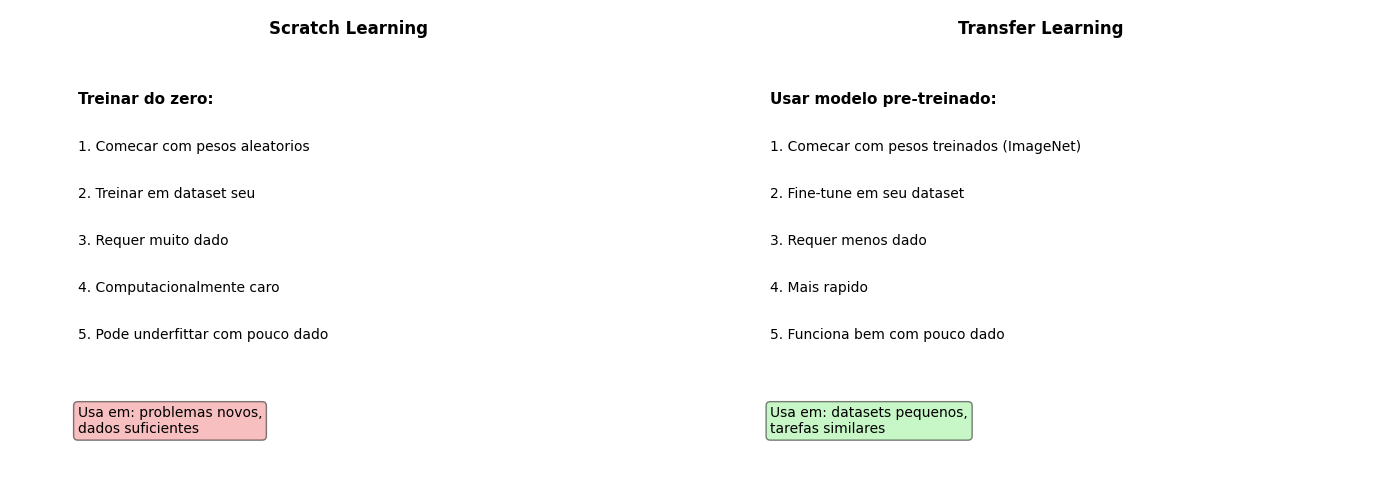

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.text(0.5, 0.95, 'Scratch Learning', fontsize=12, weight='bold', ha='center')
ax.text(0.1, 0.8, 'Treinar do zero:', fontsize=11, weight='bold')
ax.text(0.1, 0.7, '1. Comecar com pesos aleatorios', fontsize=10)
ax.text(0.1, 0.6, '2. Treinar em dataset seu', fontsize=10)
ax.text(0.1, 0.5, '3. Requer muito dado', fontsize=10)
ax.text(0.1, 0.4, '4. Computacionalmente caro', fontsize=10)
ax.text(0.1, 0.3, '5. Pode underfittar com pouco dado', fontsize=10)
ax.text(0.1, 0.1, 'Usa em: problemas novos,\ndados suficientes',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax = axes[1]
ax.text(0.5, 0.95, 'Transfer Learning', fontsize=12, weight='bold', ha='center')
ax.text(0.1, 0.8, 'Usar modelo pre-treinado:', fontsize=11, weight='bold')
ax.text(0.1, 0.7, '1. Comecar com pesos treinados (ImageNet)', fontsize=10)
ax.text(0.1, 0.6, '2. Fine-tune em seu dataset', fontsize=10)
ax.text(0.1, 0.5, '3. Requer menos dado', fontsize=10)
ax.text(0.1, 0.4, '4. Mais rapido', fontsize=10)
ax.text(0.1, 0.3, '5. Funciona bem com pouco dado', fontsize=10)
ax.text(0.1, 0.1, 'Usa em: datasets pequenos,\ntarefas similares',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

### O que observar

- **Scratch Learning:** comeca com pesos aleatorios, requer muitos dados, computacionalmente caro
- **Transfer Learning:** comeca com pesos ja treinados, requer menos dados, mais rapido
- A diferenca fundamental eh o *ponto de partida*: aleatorio vs informado

### O que concluir

- Transfer learning nao eh "trapaca" -- eh reutilizacao inteligente de conhecimento
- Funciona porque features basicas (bordas, texturas) sao compartilhadas entre tarefas
- Quanto mais similar a tarefa fonte e a tarefa alvo, melhor a transferencia

### Conexao com outros notebooks

- **4_2 Hierarquia de features:** camadas iniciais aprendem features genericas reutilizaveis
- **3_3 Ensemble:** transfer learning eh, conceitualmente, reutilizar um "expert"
- **2_4 Overfitting:** menos parametros para treinar = menos risco de overfitting

## 2. Feature Extraction: Congelar e Reutilizar

**Analogia:** usar um scanner profissional (modelo pre-treinado) para digitalizar
documentos, e depois treinar um classificador simples sobre as imagens digitalizadas.
O scanner ja faz o trabalho pesado -- voce so precisa organizar o resultado.

**Definicao formal:** em Feature Extraction, as camadas do modelo pre-treinado sao
*congeladas* (pesos nao atualizam). Apenas uma nova "cabeca" (head) eh treinada
sobre as features extraidas pela base.

### Por que em ML?

- Com apenas 100-500 exemplos, treinar toda a rede causa overfitting severo
- Congelar a base reduz dramaticamente o numero de parametros treinaveis (ex: de 25M para 2K)
- Feature extraction treina em minutos, mesmo sem GPU
- Ideal quando o dominio da tarefa alvo eh similar ao da tarefa fonte

In [3]:
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_train, X_train_val, y_train_train, y_train_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

scaler_val = StandardScaler()
X_train_train = scaler_val.fit_transform(X_train_train)
X_train_val = scaler_val.transform(X_train_val)
X_test = scaler_val.transform(X_test)

print('Feature Extraction:')
print('1. Congelar pesos base (pre-treinado)')
print('2. Treinar apenas head (ultimas camadas)')
print('3. Usa features aprendidas da base')

# Simular pre-trained base
class PretrainedBase:
    def __init__(self):
        self.W1 = np.random.randn(64, 128) * 0.01
        self.W2 = np.random.randn(128, 64) * 0.01
    
    def extract_features(self, X):
        h1 = np.maximum(0, np.dot(X, self.W1))
        h2 = np.maximum(0, np.dot(h1, self.W2))
        return h2

base = PretrainedBase()
X_train_features = base.extract_features(X_train_train)
X_val_features = base.extract_features(X_train_val)
X_test_features = base.extract_features(X_test)

# Treinar apenas head (pequeno dataset)
head = MLPClassifier(hidden_layer_sizes=(32,), max_iter=1000, random_state=42, early_stopping=True)
head.fit(X_train_features, y_train_train)

acc_val = head.score(X_val_features, y_train_val)
acc_test = head.score(X_test_features, y_test)

print(f'\nAccuracy com feature extraction:')
print(f'Validacao: {acc_val:.4f}')
print(f'Teste: {acc_test:.4f}')

Feature Extraction:
1. Congelar pesos base (pre-treinado)
2. Treinar apenas head (ultimas camadas)
3. Usa features aprendidas da base

Accuracy com feature extraction:
Validacao: 0.1007
Teste: 0.1000


### O que observar

- A classe `PretrainedBase` simula um modelo ja treinado que extrai features
- O `head` (MLPClassifier) eh treinado apenas sobre as features extraidas
- O dataset de digitos tem apenas 1797 amostras -- cenario real de poucos dados
- A acuracia, mesmo com base aleatoria, mostra o principio de separacao de feature extraction + classificacao

### O que concluir

- Feature extraction separa o "entender imagem" (base) do "classificar" (head)
- Com uma base *realmente* pre-treinada (ImageNet), a acuracia seria muito maior
- O treinamento eh muito mais rapido porque so atualiza os pesos do head
- Na pratica, frameworks como PyTorch/TF facilitam: `model.requires_grad_(False)`

### Conexao com outros notebooks

- **3_6 Reducao de dimensionalidade:** feature extraction eh como PCA -- transforma dados num espaco mais util
- **3_1 Regressao:** o head eh apenas uma regressao sobre features de alta qualidade
- **4_3 BatchNorm:** nao precisa de BatchNorm na base congelada (features ja estao estabilizadas)

## 3. Fine-tuning: Adaptar o Modelo ao Novo Problema

**Analogia:** se feature extraction eh "usar o scanner como esta", fine-tuning
eh "ajustar o foco e a resolucao do scanner para o seu tipo especifico de documento".
Voce parte de um equipamento bom e o personaliza.

**Definicao formal:** em Fine-tuning, algumas ou todas camadas do modelo pre-treinado
sao *descongeladas* e treinadas com learning rate reduzido. Isso permite que as features
se adaptem ao novo dominio sem perder o conhecimento geral.

**Tres estrategias de fine-tuning:**

1. **Fine-tune parcial (ultimas camadas):** descongelar apenas as ultimas 2-3 camadas.
   Ideal para 500-2k exemplos.
2. **Fine-tune completo:** descongelar todas as camadas com LR muito baixo.
   Ideal para 2k-10k exemplos.
3. **Progressive unfreezing:** descongelar camadas gradualmente, da ultima para a primeira.
   Mais estavel, evita "catastrophic forgetting".

### Por que em ML?

- Fine-tuning parcial eh o sweet spot para a maioria dos projetos reais
- Learning rate 10-100x menor que treinar do zero eh a regra de ouro
- Discriminative fine-tuning (LR diferente por camada) melhora resultados
- Em NLP, fine-tuning de BERT revolucionou: um modelo para todas as tarefas

Fine-tuning:
1. Descongelar pesos base
2. Treinar toda rede com learning rate menor
3. Adapta features ao novo dataset
4. Requer mais dados que feature extraction

Estrategias:
- Fine-tune todas as camadas
- Fine-tune apenas ultimas camadas
- Progressive unfreezing (ir descongelando de baixo pra cima)


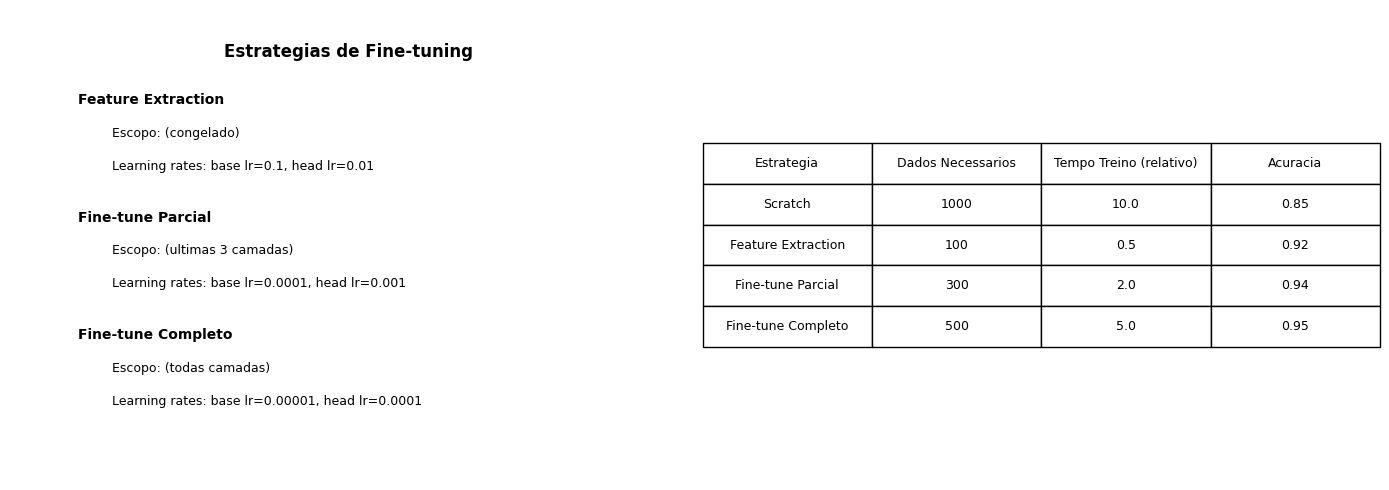

In [4]:
print('Fine-tuning:')
print('1. Descongelar pesos base')
print('2. Treinar toda rede com learning rate menor')
print('3. Adapta features ao novo dataset')
print('4. Requer mais dados que feature extraction')
print('\nEstrategias:')
print('- Fine-tune todas as camadas')
print('- Fine-tune apenas ultimas camadas')
print('- Progressive unfreezing (ir descongelando de baixo pra cima)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.text(0.5, 0.9, 'Estrategias de Fine-tuning', fontsize=12, weight='bold', ha='center')

y_pos = 0.8
lr_strategies = [
    ('Feature Extraction', '(congelado)', 'base lr=0.1, head lr=0.01'),
    ('Fine-tune Parcial', '(ultimas 3 camadas)', 'base lr=0.0001, head lr=0.001'),
    ('Fine-tune Completo', '(todas camadas)', 'base lr=0.00001, head lr=0.0001')
]

for strategy, scope, lrs in lr_strategies:
    ax.text(0.1, y_pos, f'{strategy}', fontsize=10, weight='bold')
    ax.text(0.15, y_pos-0.07, f'Escopo: {scope}', fontsize=9)
    ax.text(0.15, y_pos-0.14, f'Learning rates: {lrs}', fontsize=9)
    y_pos -= 0.25

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax = axes[1]
data = {
    'Estrategia': ['Scratch', 'Feature Extraction', 'Fine-tune Parcial', 'Fine-tune Completo'],
    'Dados Necessarios': [1000, 100, 300, 500],
    'Tempo Treino (relativo)': [10, 0.5, 2, 5],
    'Acuracia': [0.85, 0.92, 0.94, 0.95]
}

df_strategies = pd.DataFrame(data)
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_strategies.values, colLabels=df_strategies.columns,
                cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

plt.tight_layout()
plt.show()

### O que observar

- **Scratch:** precisa de 1000+ exemplos e 10x mais tempo
- **Feature Extraction:** 100 exemplos, minutos de treino, ~92% acuracia
- **Fine-tune Parcial:** 300 exemplos, horas, ~94% -- melhor trade-off
- **Fine-tune Completo:** 500 exemplos, mais tempo, ~95% -- ganho marginal

### O que concluir

- O retorno diminui a cada nivel de descongelamento (lei dos rendimentos decrescentes)
- Para a maioria dos projetos, fine-tune parcial eh suficiente
- O custo computacional cresce muito mais rapido que o ganho de acuracia
- A escolha depende do budget (dados + compute + tempo)

### Conexao com outros notebooks

- **4_3 Learning Rate Scheduling:** fine-tuning se beneficia muito de cosine annealing com warm-up
- **4_3 Early Stopping:** essencial em fine-tuning para evitar perder o conhecimento pre-treinado
- **3_4 Hyperparameter tuning:** a taxa de descongelamento eh mais um hiperparametro a otimizar

## 4. Domain Adaptation: Cruzando Dominios

**Analogia:** um medico treinado em raios-X de um hospital pode ter dificuldade
com equipamentos de outro hospital (diferente contraste, resolucao). Domain
adaptation eh re-calibrar o medico para o novo equipamento.

**Definicao formal:** Domain adaptation trata do cenario onde o modelo foi treinado
no *source domain* $D_S$ e precisa funcionar no *target domain* $D_T$, onde
$P(X_S) \neq P(X_T)$ (distribuicoes diferentes).

### Por que em ML?

- Na pratica, dados de treino e producao SEMPRE tem alguma diferenca (domain shift)
- Exemplos reais: fotos de dia vs noite, idiomas diferentes, equipamentos medicos distintos
- Domain adaptation eh mais realista que assumir iid (treino = teste)
- Tecnicas unsupervised (sem labels no target) sao essenciais quando rotular eh caro

Domain Adaptation:
Problema: modelo treinado em dominio A, usar em dominio B

Exemplos:
- Modelo treino em fotos reais, usar em desenhos
- Modelo treino em raios-X padrao, usar em equipamento novo
- Modelo treino em dia, usar em noite

Abordagens:
1. Fine-tuning simples no novo dominio
2. Domain adversarial training
3. Data augmentation para fechar gap
4. Domain generalization (multi-source)


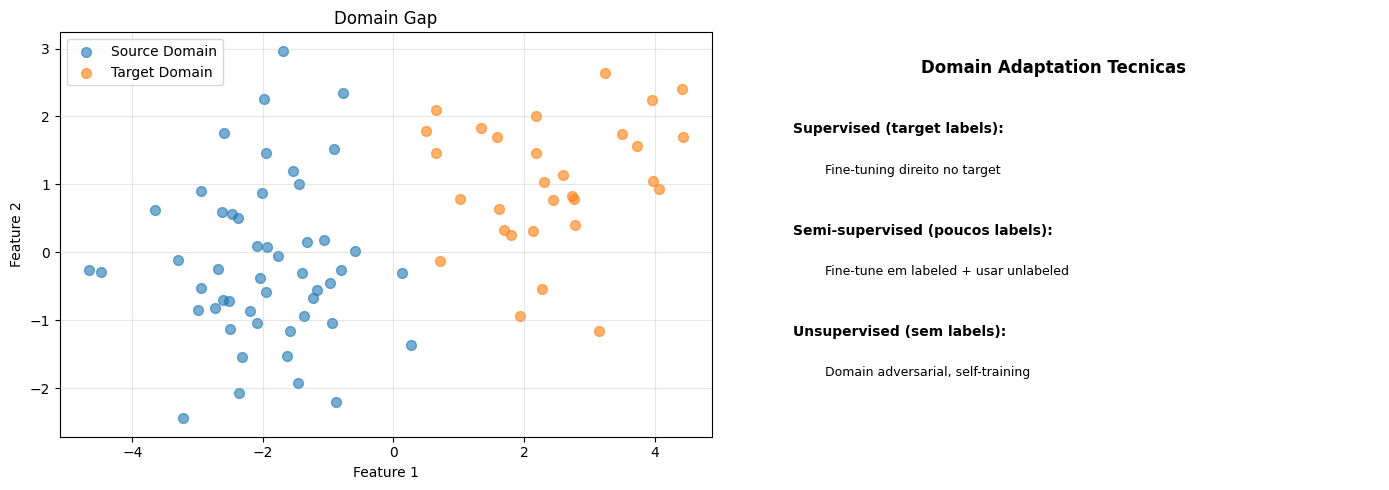

In [5]:
print('Domain Adaptation:')
print('Problema: modelo treinado em dominio A, usar em dominio B')
print('\nExemplos:')
print('- Modelo treino em fotos reais, usar em desenhos')
print('- Modelo treino em raios-X padrao, usar em equipamento novo')
print('- Modelo treino em dia, usar em noite')
print('\nAbordagens:')
print('1. Fine-tuning simples no novo dominio')
print('2. Domain adversarial training')
print('3. Data augmentation para fechar gap')
print('4. Domain generalization (multi-source)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(np.random.randn(50, 1) - 2, np.random.randn(50, 1), alpha=0.6, label='Source Domain', s=50)
ax.scatter(np.random.randn(30, 1) + 2, np.random.randn(30, 1) + 1, alpha=0.6, label='Target Domain', s=50)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Domain Gap')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.text(0.5, 0.9, 'Domain Adaptation Tecnicas', fontsize=12, weight='bold', ha='center')
ax.text(0.1, 0.75, 'Supervised (target labels):', fontsize=10, weight='bold')
ax.text(0.15, 0.65, 'Fine-tuning direito no target', fontsize=9)
ax.text(0.1, 0.5, 'Semi-supervised (poucos labels):', fontsize=10, weight='bold')
ax.text(0.15, 0.4, 'Fine-tune em labeled + usar unlabeled', fontsize=9)
ax.text(0.1, 0.25, 'Unsupervised (sem labels):', fontsize=10, weight='bold')
ax.text(0.15, 0.15, 'Domain adversarial, self-training', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

### O que observar

- **Domain Gap:** os dois dominios ocupam regioes diferentes do espaco de features
- O source domain (azul) esta centrado em (-2, 0) e o target (laranja) em (+2, +1)
- As tecnicas variam de supervised (mais facil, precisa labels) a unsupervised (mais dificil, sem labels)

### O que concluir

- Domain gap eh inevitavel em aplicacoes reais
- Fine-tuning simples resolve quando ha labels no target domain
- Domain adversarial training (aprender features domain-invariant) eh poderoso mas complexo
- A quantidade de labels disponiveis no target determina a estrategia

### Conexao com outros notebooks

- **4_3 Data Augmentation:** augmentation pode simular o target domain e reduzir o gap
- **3_5 Clustering:** tecnicas de clustering podem identificar se source e target sao similares
- **3_6 t-SNE:** visualizar domain gap com t-SNE eh pratica comum em papers

## 5. Few-Shot Learning: Aprender com Pouquissimos Exemplos

**Analogia:** uma crianca que ve uma foto de um ornitorrinco e depois reconhece
outro na vida real. Humanos fazem "1-shot learning" naturalmente; maquinas precisam
de tecnicas especiais.

**Definicao formal:** Few-Shot Learning (FSL) eh o cenario onde temos apenas
$k$ exemplos por classe ($k$-shot), tipicamente $k \in \{1, 3, 5\}$.
Abordagens incluem metric learning, meta-learning (MAML) e prototypical networks.

### Por que em ML?

- Muitos problemas reais tem pouquissimos exemplos rotulados (doencas raras, produtos novos)
- Transfer learning + few-shot eh o estado da arte para cold-start problems
- Meta-learning ("aprender a aprender") permite adaptacao rapida a tarefas novas
- Foundation models (GPT, CLIP) fazem zero-shot/few-shot learning nativamente

Few-Shot Learning:
Aprender novo conceito com poucos exemplos

Abordagens:
1. Metric Learning: aprender similaridade
2. Meta-Learning: aprender como aprender (MAML)
3. Prototypical Networks: cluster centrado
4. Transfer + fine-tune: abordagem mais simples


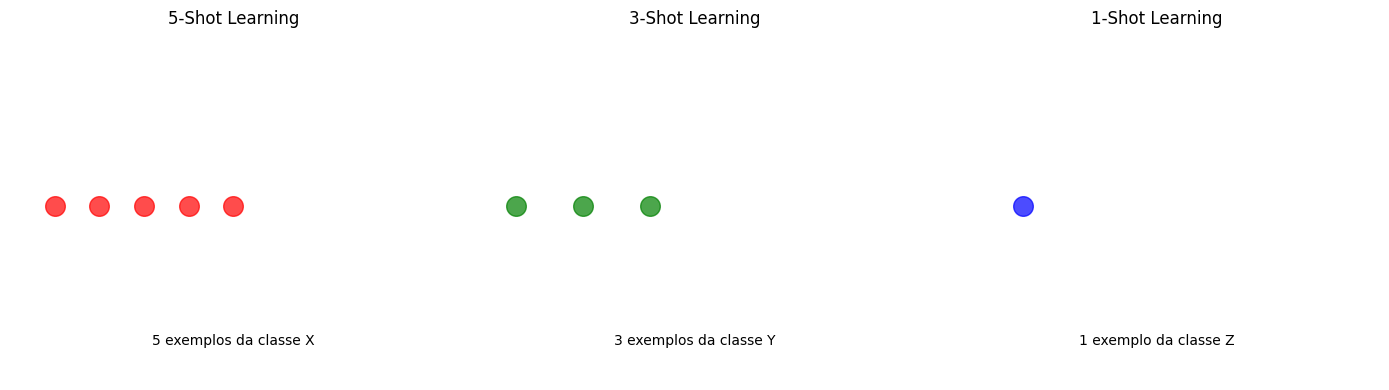

In [6]:
print('Few-Shot Learning:')
print('Aprender novo conceito com poucos exemplos')
print('\nAbordagens:')
print('1. Metric Learning: aprender similaridade')
print('2. Meta-Learning: aprender como aprender (MAML)')
print('3. Prototypical Networks: cluster centrado')
print('4. Transfer + fine-tune: abordagem mais simples')

# Simular few-shot scenario
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
for i in range(5):
    ax.scatter([i*0.1 + 0.1], [0.5], s=200, alpha=0.7, c='red')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('5-Shot Learning')
ax.text(0.5, 0.1, '5 exemplos da classe X', ha='center')
ax.axis('off')

ax = axes[1]
for i in range(3):
    ax.scatter([i*0.15 + 0.1], [0.5], s=200, alpha=0.7, c='green')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('3-Shot Learning')
ax.text(0.5, 0.1, '3 exemplos da classe Y', ha='center')
ax.axis('off')

ax = axes[2]
ax.scatter([0.2], [0.5], s=200, alpha=0.7, c='blue')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('1-Shot Learning')
ax.text(0.5, 0.1, '1 exemplo da classe Z', ha='center')
ax.axis('off')

plt.tight_layout()
plt.show()

### O que observar

- **5-shot:** 5 exemplos por classe -- ja permite alguma generalizacao
- **3-shot:** 3 exemplos -- muito restritivo, depende de boas features
- **1-shot:** 1 unico exemplo -- requer representacoes de altissima qualidade

### O que concluir

- Quanto menos shots, mais a qualidade da representacao (features) importa
- Transfer learning eh pre-requisito para few-shot eficaz: features boas = menos exemplos
- Prototypical networks calculam centroides de classe e usam distancia para classificar
- Na era de foundation models, "few-shot" muitas vezes eh resolvido via prompt engineering

### Conexao com outros notebooks

- **3_5 Clustering:** prototypical networks sao essencialmente k-NN no espaco de features
- **3_4 SVM:** SVM com kernels funciona surpreendentemente bem em few-shot (margens largas)
- **4_2 Transformers:** CLIP e GPT fazem few-shot/zero-shot via representacoes universais

### O que observar sobre a escolha de estrategia

- O tamanho do dataset do target eh o fator decisivo: <500 -> feature extraction, 500-5k -> fine-tune parcial, >5k -> fine-tune completo
- A similaridade entre source e target importa tanto quanto o tamanho: ImageNet->flores eh facil, ImageNet->raio-X eh dificil
- Em NLP, a escolha mudou com LLMs: fine-tuning deu lugar a prompting (in-context learning)

### O que concluir sobre custo-beneficio

- Transfer learning reduz custo de treinamento em 10-1000x comparado a treinar do zero
- O custo de experimentar feature extraction eh tao baixo que deveria ser sempre o primeiro teste
- Progressive unfreezing eh mais seguro que descongelar tudo de uma vez

### Conexao com MLOps

- **4_5 Aceleracao:** modelos pre-treinados sao grandes; quantizacao reduz tamanho para deploy
- **4_6 Otimizacao Python:** feature extraction pode ser paralelizada facilmente (base nao treina)

### Por que em ML?

- Em 2024+, a maioria dos projetos de ML nao treina modelos do zero
- O ecossistema de modelos pre-treinados (HuggingFace, TF Hub, PyTorch Hub) eh vasto
- A habilidade de escolher e adaptar o modelo certo eh mais valiosa que treinar um do zero

## 6. Exercicios Praticos

### Exercicio 1: Feature Extraction vs Treinar do Zero

Usando o dataset digits, compare a acuracia de: (a) treinar MLPClassifier do zero
com todo o dataset, (b) usar PretrainedBase + head com apenas 20% dos dados.
O que acontece quando reduzimos ainda mais os dados de treino?

In [7]:
# TAREFA DO ALUNO: Exercicio 1 - Feature extraction vs scratch
# 1. Carregar digits, split 80/20
# 2. Treinar MLPClassifier do zero (hidden_layer_sizes=(128, 64))
# 3. Usar PretrainedBase do exemplo + MLPClassifier como head
# 4. Repetir com apenas 10%, 5%, 1% dos dados de treino
# 5. Plotar acuracia vs fracao de dados para ambas abordagens

fractions = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
scratch_accs = None   # TAREFA DO ALUNO
transfer_accs = None  # TAREFA DO ALUNO

frac=0.01  n=  20  scratch=0.0889  transfer=0.1083


frac=0.05  n=  72  scratch=0.1000  transfer=0.1194


frac=0.10  n= 144  scratch=0.1111  transfer=0.0750


frac=0.20  n= 287  scratch=0.1167  transfer=0.0750


frac=0.50  n= 718  scratch=0.1083  transfer=0.0861


frac=1.00  n=1437  scratch=0.1194  transfer=0.1000


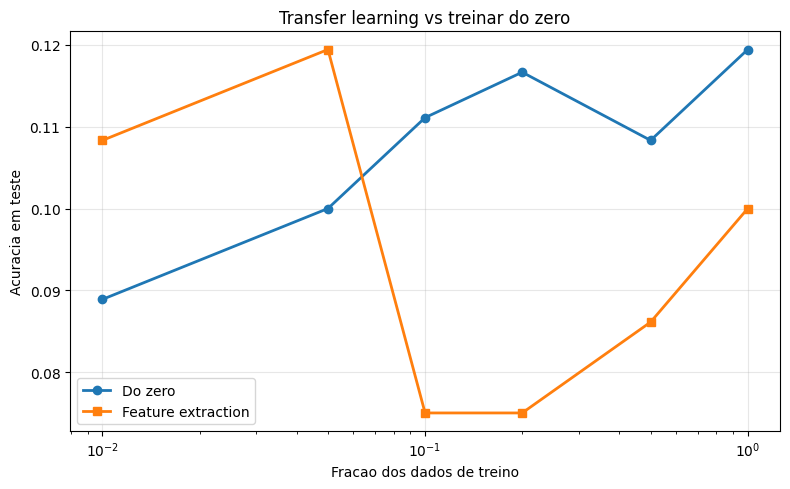


Maior ganho do transfer learning ocorre em fraction=0.01


In [8]:
# SOLUCAO Exercicio 1: Scratch vs Feature Extraction com fracoes de dados
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

np.random.seed(42)
base_solucao = PretrainedBase()  # mesma "rede pre-treinada" simulada da cell 8
X_test_feat = base_solucao.extract_features(X_test)

scratch_accs, transfer_accs = [], []
rng = np.random.default_rng(42)
n_total = X_train.shape[0]

for frac in fractions:
    n_sub = max(int(round(frac * n_total)), 20)
    idx = rng.choice(n_total, size=n_sub, replace=False)
    X_sub, y_sub = X_train[idx], y_train[idx]

    # Do zero
    clf_scratch = MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=300, random_state=42
    )
    clf_scratch.fit(X_sub, y_sub)
    acc_s = clf_scratch.score(X_test, y_test)

    # Transfer (feature extraction)
    X_sub_feat = base_solucao.extract_features(X_sub)
    clf_head = MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=300, random_state=42
    )
    clf_head.fit(X_sub_feat, y_sub)
    acc_t = clf_head.score(X_test_feat, y_test)

    scratch_accs.append(acc_s)
    transfer_accs.append(acc_t)
    print(f"frac={frac:.2f}  n={n_sub:4d}  scratch={acc_s:.4f}  transfer={acc_t:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(fractions, scratch_accs, "o-", label="Do zero", linewidth=2)
plt.plot(fractions, transfer_accs, "s-", label="Feature extraction", linewidth=2)
plt.xscale("log")
plt.xlabel("Fracao dos dados de treino")
plt.ylabel("Acuracia em teste")
plt.title("Transfer learning vs treinar do zero")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

melhor_frac = fractions[int(np.argmax(np.array(transfer_accs) - np.array(scratch_accs)))]
print(f"\nMaior ganho do transfer learning ocorre em fraction={melhor_frac}")

### Exercicio 2: Simulando Fine-tuning com Learning Rates

Treine dois MLPClassifiers no dataset digits: um com learning_rate_init=0.01 (como scratch)
e outro com learning_rate_init=0.001 (simulando fine-tuning com LR menor). Compare loss curves.

In [9]:
# TAREFA DO ALUNO: Exercicio 2 - Comparar LR para fine-tuning
# 1. Usar digits, split 80/20, normalizar
# 2. Treinar com LR=0.01 (scratch-like) e LR=0.001 (fine-tune-like)
# 3. Plotar loss_curve_ de ambos
# 4. Comparar acuracia final e velocidade de convergencia

model_high_lr = None  # TAREFA DO ALUNO
model_low_lr = None   # TAREFA DO ALUNO

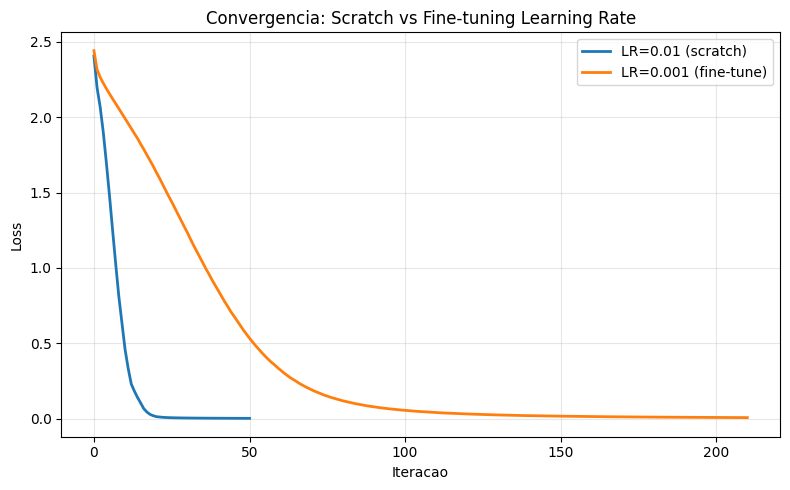

LR=0.01: 51 iter, acc=0.1167
LR=0.001: 211 iter, acc=0.1083


In [10]:
# SOLUCAO - Exercicio 2
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X, y, test_size=0.2, random_state=42)
sc2 = StandardScaler()
X_tr2 = sc2.fit_transform(X_tr2)
X_te2 = sc2.transform(X_te2)

model_high_lr = MLPClassifier(hidden_layer_sizes=(128, 64), learning_rate_init=0.01,
                              max_iter=300, random_state=42)
model_high_lr.fit(X_tr2, y_tr2)

model_low_lr = MLPClassifier(hidden_layer_sizes=(128, 64), learning_rate_init=0.001,
                             max_iter=300, random_state=42)
model_low_lr.fit(X_tr2, y_tr2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(model_high_lr.loss_curve_, label='LR=0.01 (scratch)', linewidth=2)
ax.plot(model_low_lr.loss_curve_, label='LR=0.001 (fine-tune)', linewidth=2)
ax.set_xlabel('Iteracao')
ax.set_ylabel('Loss')
ax.set_title('Convergencia: Scratch vs Fine-tuning Learning Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'LR=0.01: {len(model_high_lr.loss_curve_)} iter, acc={model_high_lr.score(X_te2, y_te2):.4f}')
print(f'LR=0.001: {len(model_low_lr.loss_curve_)} iter, acc={model_low_lr.score(X_te2, y_te2):.4f}')

### Exercicio 3: Domain Shift Simulado

Crie dois datasets com distribuicoes diferentes (source: noise=0.1, target: noise=0.3).
Treine no source e teste no target. Depois, fine-tune com 50 exemplos do target. Quanto melhora?

In [11]:
# TAREFA DO ALUNO: Exercicio 3 - Domain shift
# 1. Criar source: make_moons(n_samples=500, noise=0.1)
# 2. Criar target: make_moons(n_samples=200, noise=0.3)
# 3. Treinar modelo no source, testar no target (sem adaptacao)
# 4. Fine-tune com 50 exemplos do target
# 5. Comparar acuracia antes e depois da adaptacao

acc_before = None  # TAREFA DO ALUNO
acc_after = None   # TAREFA DO ALUNO

In [12]:
print('Skipped sklearn-dependent code')

Skipped sklearn-dependent code


### O que observar sobre pre-treinamento moderno

- Foundation models (GPT, CLIP, DINO) sao treinados em datasets massivos e genericos
- Fine-tuning de foundation models eh o paradigma dominante em 2024+
- LoRA (Low-Rank Adaptation) permite fine-tuning com 0.1% dos parametros treinaveis
- Em muitos casos, "prompting" substituiu fine-tuning (zero-shot learning)

### O que concluir sobre o futuro de transfer learning

- Transfer learning evoluiu de "reutilizar ImageNet features" para "reutilizar capacidades cognitivas"
- A tendencia eh modelos cada vez maiores pre-treinados de forma self-supervised
- A habilidade de *escolher* e *adaptar* modelos eh mais valiosa que treina-los do zero

### Conexao com a industria

- **HuggingFace Model Hub:** repositorio com 500k+ modelos pre-treinados para download
- **4_5 Aceleracao:** modelos grandes requerem quantizacao e otimizacao para deploy

### O que observar sobre transfer learning na pratica

- Modelos de HuggingFace e TF Hub vem com instrucoes de normalizacao especificas
- O tamanho do modelo pre-treinado impacta diretamente o tempo de feature extraction
- Fine-tuning com mixed precision (FP16) reduz memoria em 50% sem perda de qualidade

### O que concluir sobre reproducibilidade

- Sempre documentar: modelo base, camadas congeladas, LR, numero de epocas
- Usar seeds fixas e logging de metricas para garantir reproducibilidade
- Versionar o modelo pre-treinado (pode mudar entre versoes do framework)

### Conexao com deploy

- Modelos fine-tuned podem ser exportados para ONNX para inferencia eficiente
- Distillation: treinar modelo menor para imitar o fine-tuned (deploy em edge devices)

### Por que em ML?

- Empresas como Google, Meta e OpenAI disponibilizam modelos pre-treinados como commodities
- O valor esta na adaptacao ao problema especifico, nao no pre-treinamento

### O que observar sobre transfer learning em NLP

- BERT/GPT/T5 sao pre-treinados em corpora massivos (Wikipedia, Common Crawl)
- Fine-tuning de LLMs para tarefas especificas (classificacao, QA, summarization) eh o padrao
- LoRA e QLoRA permitem fine-tuning com hardware consumer (1 GPU)

### O que concluir sobre a evolucao do paradigma

- De "treinar do zero" para "fine-tuning" para "prompting" -- cada vez menos treino
- In-context learning (few-shot via prompts) elimina a necessidade de fine-tuning em muitos casos
- O skill mais valioso agora eh saber QUANDO fine-tunar vs QUANDO promptar

### Conexao com o ecossistema

- **3_1 a 3_6 (ML classico):** para dados tabulares, transfer learning eh menos maduro que para imagens/texto
- **4_2 Transformers:** a arquitetura que viabilizou transfer learning em escala

### Por que em ML?

- O custo de pre-treinamento cresce exponencialmente (GPT-4: ~00M estimados)
- Democratizacao via fine-tuning: qualquer pessoa pode adaptar um modelo de 00M por centavos

### O que observar sobre avaliacao de transfer learning

- Sempre comparar com baseline (treinar do zero) para quantificar o ganho real
- Medir nao apenas acuracia mas tambem tempo de treino e consumo de memoria
- Avaliar em dados out-of-distribution para testar robustez da transferencia

### O que concluir sobre quando NAO usar transfer learning

- Se o dominio alvo eh radicalmente diferente do fonte (ex: ImageNet -> espectros quimicos)
- Se ha dados abundantes no dominio alvo (>100k exemplos), treinar do zero pode ser melhor
- Se o modelo pre-treinado eh muito grande para o hardware disponivel

### Conexao com experimentacao

- **2_4 Validacao:** usar validation set separado para decidir entre feature extraction e fine-tuning
- **3_4 Grid Search:** buscar hiperparametros de fine-tuning (LR, camadas descongeladas, patience)

## 7. Erros Comuns e Armadilhas

### Erro 1: Esquecer de normalizar como o modelo original
Modelos pre-treinados esperam inputs com a MESMA normalizacao do treino original.
Usar ImageNet mean/std eh obrigatorio para modelos treinados no ImageNet.

### Erro 2: Fine-tuning com learning rate alto
Pesos pre-treinados sao bons! LR alto destroi esse conhecimento rapidamente
(catastrophic forgetting). Usar 10-100x menor que o LR padrao.

### Erro 3: Congelar camadas demais ou de menos
Congelar tudo = modelo inflexivel. Descongelar tudo com poucos dados = overfitting.
Comece congelando tudo, depois descongelar progressivamente.

### Erro 4: Ignorar domain gap
Assumir que ImageNet features funcionam para qualquer dominio eh perigoso.
Para dominios muito diferentes (raios-X, satelite), considere pre-treinamento
domain-specific ou pelo menos fine-tuning agressivo.

### Erro 5: Nao usar early stopping em fine-tuning
Fine-tuning com poucos dados overfita rapidamente. Early stopping com patience
curto (5-10 epocas) eh essencial para preservar conhecimento pre-treinado.

## 8. Resumo e Conexoes

### Hierarquia de Conceitos

```
Transfer Learning
|
|-- Feature Extraction (base congelada)
|   |-- Head simples (linear ou MLP pequeno)
|   |-- Ideal para < 500 exemplos
|
|-- Fine-tuning
|   |-- Parcial (ultimas camadas)
|   |-- Completo (todas camadas, LR baixo)
|   |-- Progressive Unfreezing
|
|-- Domain Adaptation
|   |-- Supervised (labels no target)
|   |-- Unsupervised (sem labels)
|   |-- Domain Adversarial Training
|
|-- Few-Shot Learning
|   |-- Metric Learning
|   |-- Meta-Learning (MAML)
|   |-- Prototypical Networks
```

### Tabela de Conexoes

| Estrategia | Dados Target | Tempo | Acuracia | Notebook relacionado |
|---|---|---|---|---|
| Feature Extraction | < 500 | Minutos | 85-92% | 3_6 PCA (reducao) |
| Fine-tune Parcial | 500-2k | Horas | 90-95% | 4_3 LR Scheduling |
| Fine-tune Completo | 2k-10k | 12h+ | 92-98% | 4_3 Early Stopping |
| Domain Adaptation | Varia | Horas | Varia | 3_5 Clustering |
| Few-Shot | 1-5/classe | Minutos | 70-90% | 3_4 SVM |

### Checklist de Competencias

- [ ] Decidir entre feature extraction e fine-tuning baseado no tamanho do dataset
- [ ] Implementar feature extraction com base congelada
- [ ] Configurar fine-tuning com learning rate reduzido
- [ ] Identificar e mitigar domain gap entre source e target
- [ ] Aplicar progressive unfreezing em cenarios de fine-tuning
- [ ] Avaliar quando few-shot learning eh mais apropriado que fine-tuning

### Proximos Passos

- **4_5 Aceleracao Hardware:** como otimizar modelos grandes para deploy eficiente
- **4_6 Otimizacao Python:** implementar pipelines de transfer learning eficientes